<a href="https://colab.research.google.com/github/AmaraRao19/Telco-Customer-Churn-Pipeline/blob/main/End_to_End_ML_Pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Load Dataset

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/Telco_Customer_Churn/WA_Fn-UseC_-Telco-Customer-Churn.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


#Basic Info


In [12]:
df.info()
print("Missing Values:\n")
print(df.isnull().sum())
df['Churn'].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


,count
Churn,
No,5174
Yes,1869


In [20]:
print("Dataset Shape:", df.shape)
print("\nColumns:\n", df.columns)

Dataset Shape: (7043, 20)

Columns:
 Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')


#Churn Count Plot

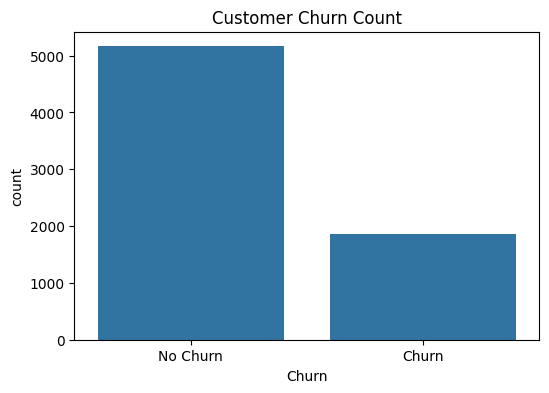

In [41]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.countplot(x='Churn', data=df)
plt.title('Customer Churn Count')
plt.xticks([0,1], ['No Churn','Churn'])
plt.show()

#Drop Unnecessary Column

In [17]:
print("\nColumns:\n", df.columns)
print("customerID column removed ")


Columns:
 Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')
customerID column removed 


In [18]:
print("New Shape:", df.shape)

New Shape: (7043, 20)


#Identify Column Types

In [21]:
categorical_cols = X.select_dtypes(include=['object']).columns
numerical_cols = X.select_dtypes(include=['int64','float64']).columns

#Fix TotalCharges

In [23]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

print("Converted TotalCharges to numeric ")
print("Missing after conversion:\n", df['TotalCharges'].isnull().sum())

Converted TotalCharges to numeric 
Missing after conversion:
 11


#Remove Null Rows

In [24]:
df.dropna(inplace=True)

print("Null values removed ")
print("New Shape:", df.shape)

Null values removed 
New Shape: (7032, 20)


#Convert Target Variable

In [25]:
df['Churn'] = df['Churn'].map({'Yes':1, 'No':0})

print("Churn column converted to numeric ")
print(df['Churn'].value_counts())

Churn column converted to numeric 
Churn
0    5163
1    1869
Name: count, dtype: int64


#Correlation Heatmap

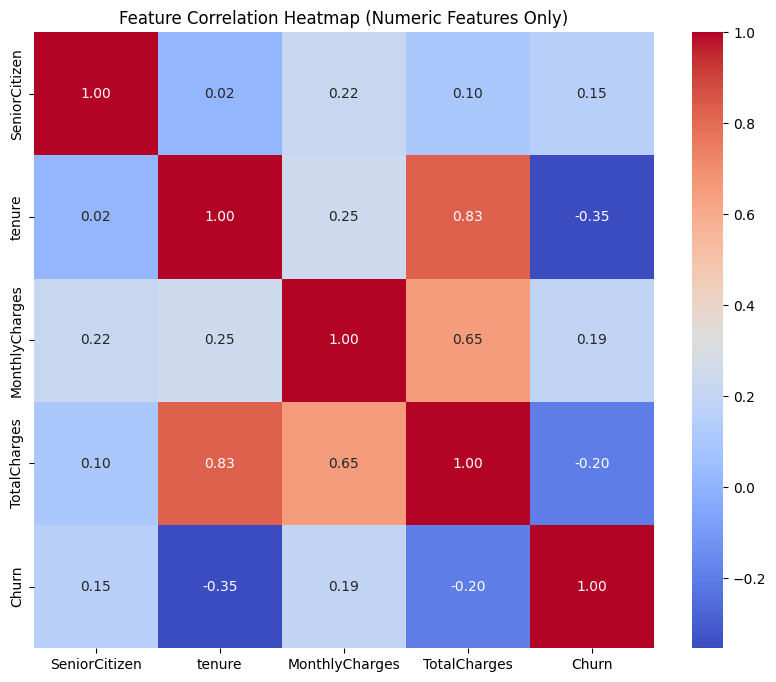

In [44]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select only numeric columns
numeric_cols = df.select_dtypes(include=['int64','float64']).columns
df_numeric = df[numeric_cols]

# Plot correlation heatmap
plt.figure(figsize=(10,8))
sns.heatmap(df_numeric.corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Feature Correlation Heatmap (Numeric Features Only)')
plt.show()

#Split Features & Target

In [26]:
X = df.drop('Churn', axis=1)
y = df['Churn']

print("Features and target separated ")
print("X shape:", X.shape)
print("y shape:", y.shape)

Features and target separated 
X shape: (7032, 19)
y shape: (7032,)


#Boxplot of TotalCharges vs Churn

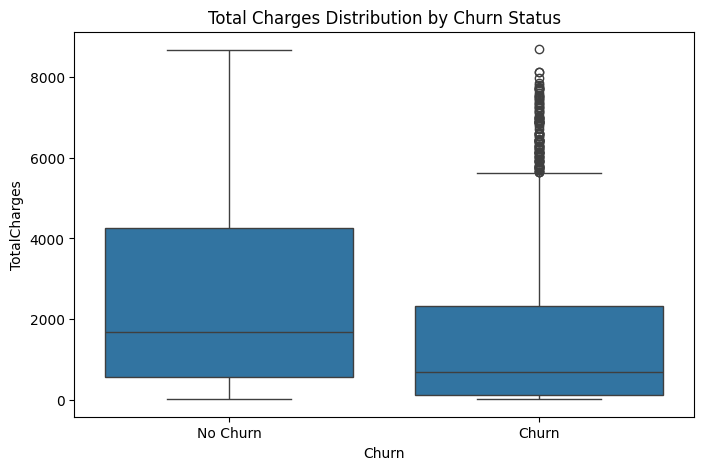

In [42]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Churn', y='TotalCharges', data=df)
plt.xticks([0,1], ['No Churn','Churn'])
plt.title('Total Charges Distribution by Churn Status')
plt.show()

#Train-Test Split

In [27]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Data split completed")
print("Training size:", X_train.shape)
print("Testing size:", X_test.shape)

Data split completed
Training size: (5625, 19)
Testing size: (1407, 19)


#Identify Column Types

In [28]:
categorical_cols = X.select_dtypes(include=['object']).columns
numerical_cols = X.select_dtypes(include=['int64','float64']).columns

print("Categorical Columns:\n", list(categorical_cols))
print("\nNumerical Columns:\n", list(numerical_cols))

Categorical Columns:
 ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Numerical Columns:
 ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']


#Churn by Tenure (Histogram)

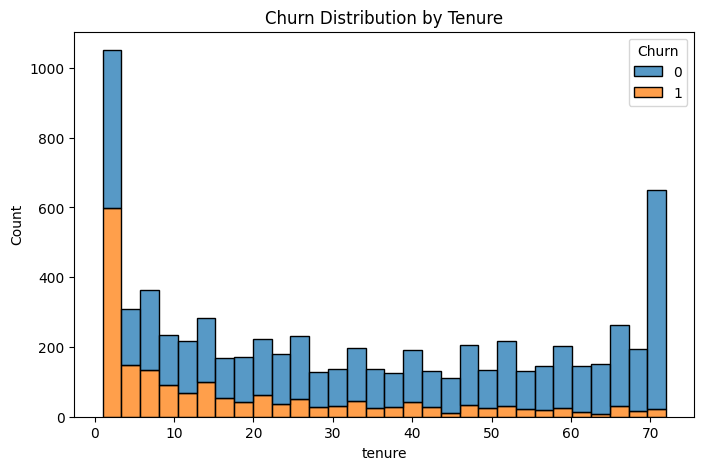

In [45]:
plt.figure(figsize=(8,5))
sns.histplot(data=df, x='tenure', hue='Churn', multiple='stack', bins=30)
plt.title('Churn Distribution by Tenure')
plt.show()

#Import Pipeline Tools

In [29]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

print("Pipeline tools imported ")

Pipeline tools imported 


#Create Transformers

In [30]:
num_pipeline = Pipeline([
    ('scaler', StandardScaler())
])

cat_pipeline = Pipeline([
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

print("Transformers created ")

Transformers created 


#Column Transformer

In [31]:
preprocessor = ColumnTransformer([
    ('num', num_pipeline, numerical_cols),
    ('cat', cat_pipeline, categorical_cols)
])

print("ColumnTransformer ready ")

ColumnTransformer ready 


#Logistic Regression Pipeline

In [32]:
from sklearn.linear_model import LogisticRegression

pipeline_lr = Pipeline([
    ('preprocessing', preprocessor),
    ('model', LogisticRegression())
])

print("Logistic Regression pipeline created ")

Logistic Regression pipeline created 


#Random Forest Pipeline

In [33]:
from sklearn.ensemble import RandomForestClassifier

pipeline_rf = Pipeline([
    ('preprocessing', preprocessor),
    ('model', RandomForestClassifier())
])

print("Random Forest pipeline created ")

Random Forest pipeline created 


#GridSearch for Logistic Regression

In [34]:
from sklearn.model_selection import GridSearchCV

param_grid_lr = {
    'model__C': [0.01, 0.1, 1, 10],
    'model__solver': ['liblinear']
}

grid_lr = GridSearchCV(pipeline_lr, param_grid_lr, cv=5, scoring='accuracy')
grid_lr.fit(X_train, y_train)

print("Best LR Parameters:", grid_lr.best_params_)

Best LR Parameters: {'model__C': 10, 'model__solver': 'liblinear'}


#GridSearch for Random Forest

In [35]:
param_grid_rf = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [5, 10, None]
}

grid_rf = GridSearchCV(pipeline_rf, param_grid_rf, cv=5, scoring='accuracy')
grid_rf.fit(X_train, y_train)

print("Best RF Parameters:", grid_rf.best_params_)

Best RF Parameters: {'model__max_depth': 10, 'model__n_estimators': 100}


#Model Evaluation

In [36]:
from sklearn.metrics import accuracy_score, classification_report

y_pred_lr = grid_lr.predict(X_test)
y_pred_rf = grid_rf.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print("\nRandom Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

print("\nRandom Forest Classification Report:\n")
print(classification_report(y_test, y_pred_rf))

Logistic Regression Accuracy: 0.7896233120113717

Random Forest Accuracy: 0.7882018479033405

Random Forest Classification Report:

              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1033
           1       0.63      0.50      0.56       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407



#Save Model

In [37]:
import joblib

best_model = grid_rf.best_estimator_

joblib.dump(best_model, "churn_pipeline.pkl")

print("Model saved successfully as churn_pipeline.pkl ")

Model saved successfully as churn_pipeline.pkl 


#Pie Chart of Contract Types

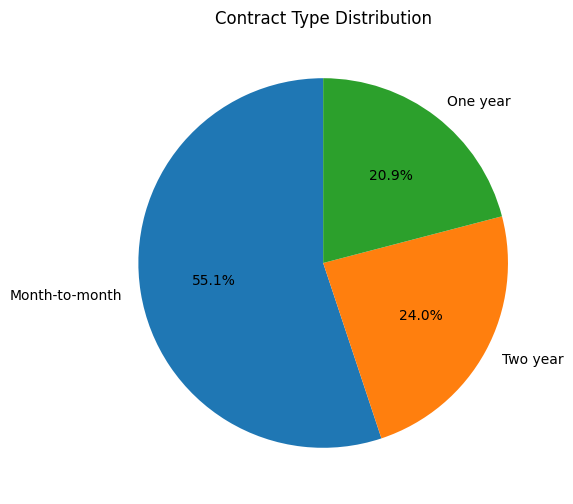

In [46]:
contract_counts = df['Contract'].value_counts()
plt.figure(figsize=(6,6))
plt.pie(contract_counts, labels=contract_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('Contract Type Distribution')
plt.show()

#Download Model

In [38]:
from google.colab import files

files.download("churn_pipeline.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

#conclusion

In [40]:
print("FINAL CONCLUSION OF TELCO CUSTOMER CHURN PROJECT\n")
print("1. Logistic Regression Accuracy: {:.2f}%".format(accuracy_score(y_test, grid_lr.predict(X_test))*100))
print("2. Random Forest Accuracy: {:.2f}%".format(accuracy_score(y_test, grid_rf.predict(X_test))*100))
print("\nObservation:")
print("- Both models achieved similar overall accuracy (~79%).")
print("- Dataset is imbalanced (more 'No Churn' than 'Churn'), so accuracy alone can be misleading.")
print("- Random Forest is slightly better at capturing complex patterns, but recall for churn (class 1) is low (~50%).")
print("- Logistic Regression is simple and gives comparable accuracy.")
print("\nRecommendation:")
print("- For production, Random Forest with class balancing or further hyperparameter tuning may improve churn prediction.")
print("- Both pipelines are reusable and can be saved for deployment using joblib.")

FINAL CONCLUSION OF TELCO CUSTOMER CHURN PROJECT

1. Logistic Regression Accuracy: 78.96%
2. Random Forest Accuracy: 78.82%

Observation:
- Both models achieved similar overall accuracy (~79%).
- Dataset is imbalanced (more 'No Churn' than 'Churn'), so accuracy alone can be misleading.
- Random Forest is slightly better at capturing complex patterns, but recall for churn (class 1) is low (~50%).
- Logistic Regression is simple and gives comparable accuracy.

Recommendation:
- For production, Random Forest with class balancing or further hyperparameter tuning may improve churn prediction.
- Both pipelines are reusable and can be saved for deployment using joblib.
